# Deep Momentum — Full Pipeline Run

Replication of Han & Qin (2026), "Bimodality Everywhere: International Evidence of Deep Momentum"

Pilot run: Canada, Korea, Australia

In [1]:
!pip install -q "pandas>=2.0" "numpy>=1.24" "xgboost>=2.0,<2.1" "scikit-learn>=1.3" requests python-dotenv pyarrow tqdm matplotlib seaborn yfinance



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings('ignore')

PILOT_COUNTRIES = ['TO', 'KS', 'AX']  # Canada, Korea, Australia
N_ENSEMBLE = 100  # paper uses 100
OOS_START = '2010-01-31'  # paper's OOS start

print('Pilot countries:', PILOT_COUNTRIES)
print(f'Ensemble size: {N_ENSEMBLE}')

Pilot countries: ['TO', 'KS', 'AX']
Ensemble size: 100


## Step 1: Data Fetch

## Step 2: Data Filtering

In [3]:
from data_filter import filter_country, check_country_eligibility
from config import COUNTRIES, DATA_DIR, CACHE_DIR
from pathlib import Path
import pandas as pd

for suffix in PILOT_COUNTRIES:
    _, country_name, _, _ = COUNTRIES[suffix]
    f = Path(DATA_DIR) / f'monthly_{suffix}.parquet'
    if not f.exists():
        print(f'No data for {suffix}')
        continue
    df = pd.read_parquet(f)
    filtered = filter_country(df, country_name)
    filtered.to_parquet(Path(CACHE_DIR) / f'filtered_{suffix}.parquet', index=False)
    eligible, reason = check_country_eligibility(filtered, suffix)
    print(f'  Eligible: {eligible} — {reason}')


  Canada: 848 stocks, 191116 obs
    Zero volume filter: dropped 877 obs (0.5%)
    MCap missing filter: dropped 958 obs (0.5%)
    MCap bottom 5% filter: dropped 9624 obs (5.1%)
    Extreme return filter: dropped 93 obs (0.1%)
    Winsorize: clipped 3574 obs at [-0.3548, 0.6248]
    After all filters: 845 stocks, 178716 obs
  Eligible: False — min stocks/month = 2, need >=30

  South Korea: 1022 stocks, 250791 obs
    Zero volume filter: dropped 1353 obs (0.5%)
    MCap missing filter: dropped 1870 obs (0.8%)
    MCap bottom 5% filter: dropped 12499 obs (5.1%)
    Extreme return filter: dropped 123 obs (0.1%)
    Winsorize: clipped 4680 obs at [-0.3047, 0.5431]
    After all filters: 1016 stocks, 233924 obs
  Eligible: False — min stocks/month = 1, need >=30

  Australia: 2311 stocks, 426214 obs
    Zero volume filter: dropped 16898 obs (4.0%)
    MCap missing filter: dropped 6760 obs (1.7%)
    MCap bottom 5% filter: dropped 20190 obs (5.0%)
    Extreme return filter: dropped 804 ob

## Step 3: Feature Construction

In [4]:
from features import build_features
from config import COUNTRIES, CACHE_DIR
from pathlib import Path
import pandas as pd

cache_dir = Path(CACHE_DIR)
features_data = {}

for suffix in PILOT_COUNTRIES:
    filtered_path = cache_dir / f'filtered_{suffix}.parquet'
    if not filtered_path.exists():
        print(f'No filtered data for {suffix}, skipping')
        continue
    
    _, country_name, _, _ = COUNTRIES[suffix]
    df = pd.read_parquet(filtered_path)
    df, feature_cols = build_features(df, country_name)
    
    # Save
    df.to_parquet(cache_dir / f'features_{suffix}.parquet', index=False)
    features_data[suffix] = (df, feature_cols)
    
print(f'\nFeatures built for {len(features_data)} countries')
print(f'Feature columns ({len(feature_cols)}): {feature_cols}')

  Building features for Canada...
    Stocks: 845
    Total obs: 178716
    Complete obs (all features + label): 168637
    Feature cols: 16
  Building features for South Korea...
    Stocks: 1016
    Total obs: 233924
    Complete obs (all features + label): 221745
    Feature cols: 16
  Building features for Australia...
    Stocks: 2277
    Total obs: 379251
    Complete obs (all features + label): 352648
    Feature cols: 16

Features built for 3 countries
Feature columns (16): ['zMOM_1', 'MMOM_1', 'SMOM_1', 'zMOM_3', 'MMOM_3', 'SMOM_3', 'zMOM_6', 'MMOM_6', 'SMOM_6', 'zMOM_9', 'MMOM_9', 'SMOM_9', 'zMOM_12', 'MMOM_12', 'SMOM_12', 'SIZE']


## Step 4: Model Training + Prediction

In [5]:
from model import run_walk_forward

predictions_data = {}

for suffix in PILOT_COUNTRIES:
    if suffix not in features_data:
        continue
    
    _, country_name, _, _ = COUNTRIES[suffix]
    df, feature_cols = features_data[suffix]
    
    print(f'\n{"="*60}')
    print(f'TRAINING: {country_name} (.{suffix})')
    print(f'{"="*60}')
    
    predictions = run_walk_forward(
        df, feature_cols,
        n_ensemble=N_ENSEMBLE,
        verbose=True,
    )
    
    if not predictions.empty:
        predictions.to_parquet(cache_dir / f'predictions_{suffix}.parquet', index=False)
        predictions_data[suffix] = predictions
        print(f'  Saved {len(predictions)} predictions')
    else:
        print(f'  No predictions generated')

print(f'\nPredictions generated for {len(predictions_data)} countries')


TRAINING: Canada (.TO)
    Training schedule: 27 retrainings
    First train: 2000-04-01
    Last train: 2026-04-01
    Training at 2000-04-01, predicting 12 months...
    Training at 2001-04-01, predicting 12 months...
    Training at 2002-04-01, predicting 12 months...
    Training at 2003-04-01, predicting 12 months...
    Training at 2004-04-01, predicting 12 months...
    Training at 2005-04-01, predicting 12 months...
    Training at 2006-04-01, predicting 12 months...
    Training at 2007-04-01, predicting 12 months...
    Training at 2008-04-01, predicting 12 months...
    Training at 2009-04-01, predicting 12 months...
    Training at 2010-04-01, predicting 12 months...
    Training at 2011-04-01, predicting 12 months...
    Training at 2012-04-01, predicting 12 months...
    Training at 2013-04-01, predicting 12 months...
    Training at 2014-04-01, predicting 12 months...
    Training at 2015-04-01, predicting 12 months...
    Training at 2016-04-01, predicting 12 months...

## Step 5: Portfolio Construction + Performance

In [6]:
from portfolio import run_all_strategies, print_performance_table

all_results = {}

for suffix in PILOT_COUNTRIES:
    if suffix not in features_data or suffix not in predictions_data:
        continue
    
    _, country_name, _, _ = COUNTRIES[suffix]
    df, feature_cols = features_data[suffix]
    predictions = predictions_data[suffix]
    
    # Merge fwd_return into predictions
    fwd = df[['symbol', 'date', 'fwd_return']].dropna()
    predictions = predictions.drop(columns=['fwd_return'], errors='ignore')
    predictions = predictions.merge(fwd, on=['symbol', 'date'], how='left')
    
    print(f'\n{"="*60}')
    print(f'{country_name}')
    print(f'{"="*60}')
    
    results = run_all_strategies(df, predictions, oos_start=OOS_START)
    print_performance_table(results)
    all_results[suffix] = results


Canada

Strategy      Ann.Ret    Ann.Vol   Sharpe    Cum.Ret    MaxDD   t-stat  Months   Avg TC
-----------------------------------------------------------------------------------
MOM            18.5%     24.2%    0.765   1122.3%  -40.9%     3.08     194    3.9bp
XGB            23.2%     13.9%    1.672   3330.3%  -14.3%     6.69     192    6.8bp
RET            32.8%     17.0%    1.921  14759.5%  -15.5%     7.72     194    9.5bp
SRP            32.3%     16.8%    1.922  13824.4%  -20.0%     7.73     194    9.9bp

South Korea

Strategy      Ann.Ret    Ann.Vol   Sharpe    Cum.Ret    MaxDD   t-stat  Months   Avg TC
-----------------------------------------------------------------------------------
MOM             9.0%     18.1%    0.497    228.7%  -54.2%     2.00     194    4.5bp
XGB            21.2%     10.1%    2.093   2610.9%  -10.3%     8.39     193    7.5bp
RET            30.7%     12.1%    2.537  12010.8%  -10.7%    10.20     194    9.5bp
SRP            31.2%     12.0%    2.605  1287

## Step 6: Full Report + Metrics

In [7]:
from metrics import full_report

for suffix in PILOT_COUNTRIES:
    if suffix not in features_data or suffix not in predictions_data:
        continue
    
    _, country_name, _, _ = COUNTRIES[suffix]
    df, feature_cols = features_data[suffix]
    predictions = predictions_data[suffix]
    
    # Merge fwd_return
    fwd = df[['symbol', 'date', 'fwd_return']].dropna()
    preds = predictions.drop(columns=['fwd_return'], errors='ignore')
    preds = preds.merge(fwd, on=['symbol', 'date'], how='left')
    
    full_report(df, preds, all_results.get(suffix, {}), country_name)


FULL REPORT — Canada

--- Portfolio Performance (Table 5 equivalent) ---
Strategy      Ann.Ret    Ann.Vol   Sharpe    Cum.Ret    MaxDD   t-stat  Months
---------------------------------------------------------------------------
MOM            18.5%     24.2%    0.765   1122.3%  -40.9%     3.08     194
XGB            23.2%     13.9%    1.672   3330.3%  -14.3%     6.69     192
RET            32.8%     17.0%    1.921  14759.5%  -15.5%     7.72     194
SRP            32.3%     16.8%    1.922  13824.4%  -20.0%     7.73     194

--- Bimodality (Table 2 equivalent) ---
  MOM:  HH=0.057  HL=0.030  LL=0.119  LH=0.074  BM=-0.036
  XGB:  HH=0.097  HL=0.069  LL=0.102  LH=0.064  BM=-0.033

--- Crash Rate ---
  MOM: 0.278
  XGB: 0.000
  RET: 0.000
  SRP: 0.000

--- Classification Accuracy (Table IA2 equivalent) ---
  Overall accuracy: 15.3%
  Precision H: 18.6%  Precision L: 19.7%
  Recall H: 25.4%  Recall L: 40.0%
  Pred ratio H: 13.6%  Pred ratio L: 20.8%

FULL REPORT — South Korea

--- Portfolio

## Plots

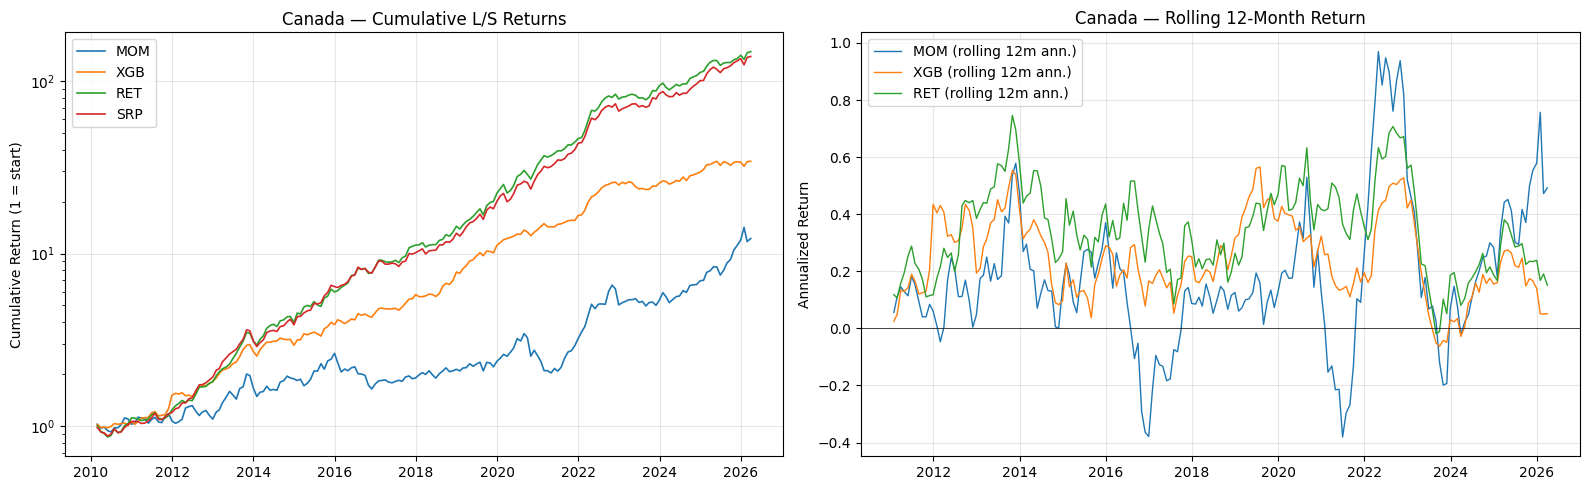

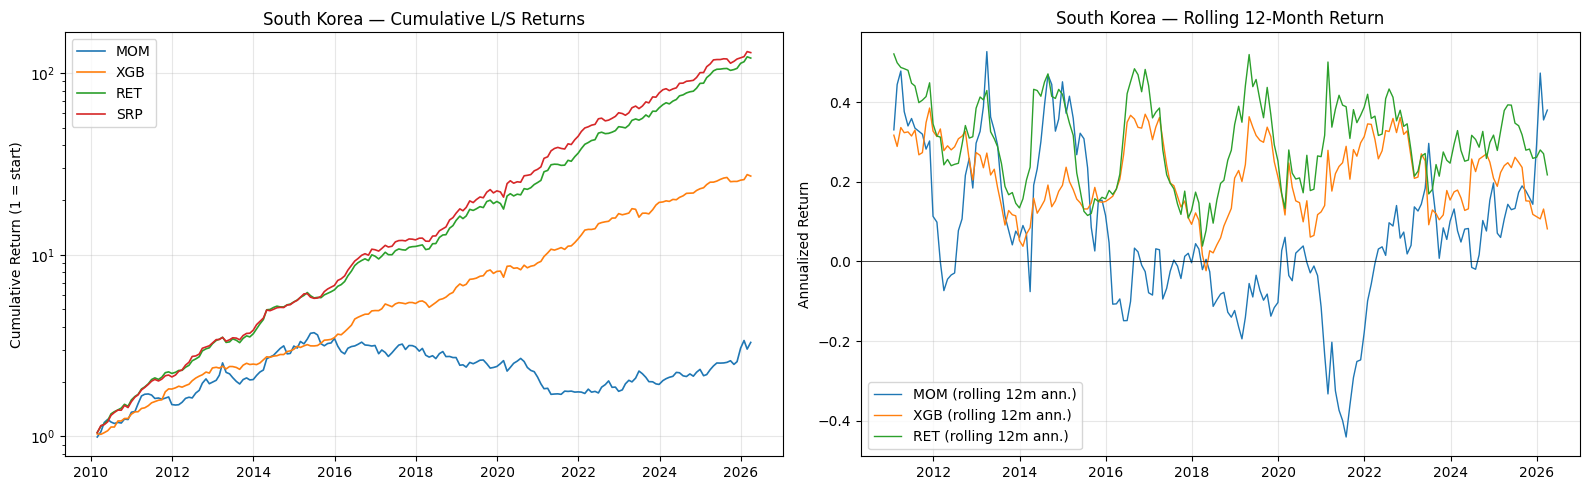

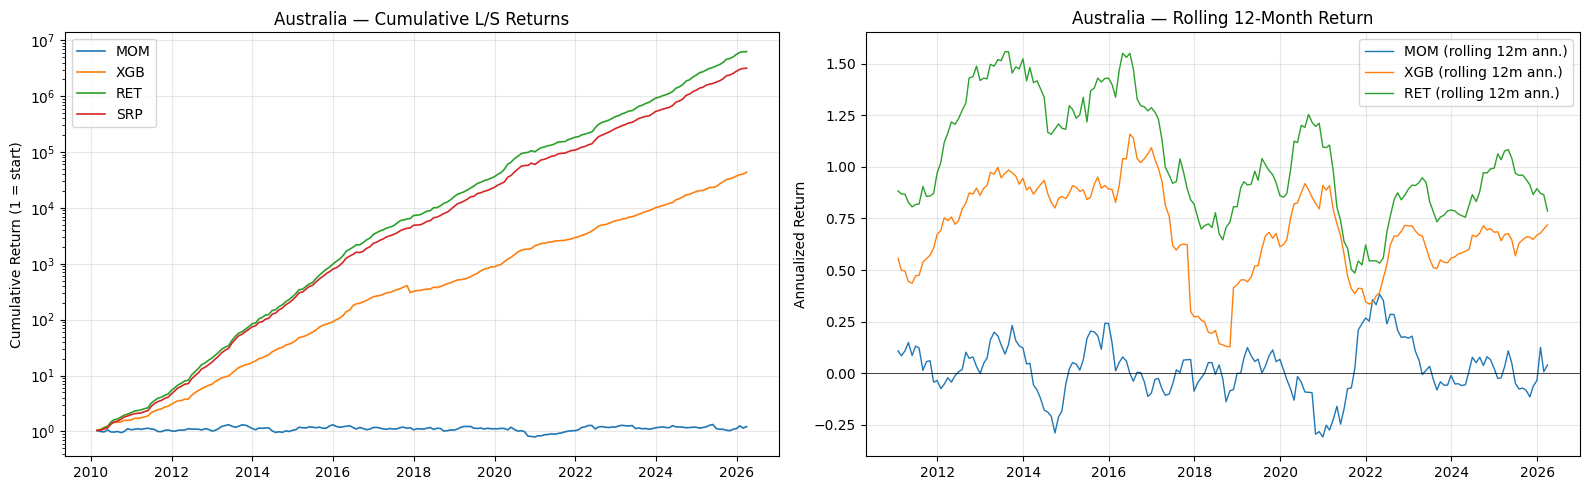

In [8]:
import matplotlib.pyplot as plt
import numpy as np

for suffix in PILOT_COUNTRIES:
    if suffix not in all_results:
        continue
    
    _, country_name, _, _ = COUNTRIES[suffix]
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Panel 1: Cumulative returns
    ax = axes[0]
    for name, color in [('MOM', '#1f77b4'), ('XGB', '#ff7f0e'), ('RET', '#2ca02c'), ('SRP', '#d62728')]:
        if name in all_results[suffix] and not all_results[suffix][name]['portfolio'].empty:
            port = all_results[suffix][name]['portfolio']
            cum = (1 + port['ls_ret']).cumprod()
            ax.plot(port['date'], cum, label=name, color=color, linewidth=1.2)
    
    ax.set_ylabel('Cumulative Return (1 = start)')
    ax.set_title(f'{country_name} — Cumulative L/S Returns')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_yscale('log')
    
    # Panel 2: Rolling 12-month return
    ax = axes[1]
    for name, color in [('MOM', '#1f77b4'), ('XGB', '#ff7f0e'), ('RET', '#2ca02c')]:
        if name in all_results[suffix] and not all_results[suffix][name]['portfolio'].empty:
            port = all_results[suffix][name]['portfolio']
            rolling = port['ls_ret'].rolling(12).mean() * 12
            ax.plot(port['date'], rolling, label=f'{name} (rolling 12m ann.)', 
                    color=color, linewidth=1)
    
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_ylabel('Annualized Return')
    ax.set_title(f'{country_name} — Rolling 12-Month Return')
    ax.legend()
    ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'results/{suffix}_performance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print()

## Cross-Country Comparison (Table 5 equivalent)

In [9]:
print(f'{"Country":<15s} {"":>5s} {"MOM":>12s} {"XGB":>12s} {"RET":>12s} {"SRP":>12s}')
print(f'{"":>20s} {"Ret / Sharpe":>12s} {"Ret / Sharpe":>12s} {"Ret / Sharpe":>12s} {"Ret / Sharpe":>12s}')
print('-' * 75)

for suffix in PILOT_COUNTRIES:
    if suffix not in all_results:
        continue
    _, country_name, _, _ = COUNTRIES[suffix]
    
    parts = [f'{country_name:<15s}', f'{"":>5s}']
    for name in ['MOM', 'XGB', 'RET', 'SRP']:
        if name in all_results[suffix] and all_results[suffix][name]['metrics']:
            m = all_results[suffix][name]['metrics']
            parts.append(f'{m["mean_annual"]:>5.1%}/{m["sharpe"]:>5.2f}')
        else:
            parts.append(f'{"N/A":>12s}')
    
    print('  '.join(parts))

Country                        MOM          XGB          RET          SRP
                     Ret / Sharpe Ret / Sharpe Ret / Sharpe Ret / Sharpe
---------------------------------------------------------------------------
Canada                  18.5%/ 0.77  23.2%/ 1.67  32.8%/ 1.92  32.3%/ 1.92
South Korea              9.0%/ 0.50  21.2%/ 2.09  30.7%/ 2.54  31.2%/ 2.61
Australia                2.7%/ 0.16  69.0%/ 4.75  102.1%/ 5.98  97.5%/ 5.96


## Fixed-N Variant — Top 10 / Bottom 10 per Country per Month

Paper uses decile cuts (top/bottom 10%), which scales the portfolio with universe size. For practical execution we re-run all four strategies selecting a **fixed number** of names per country-month, ranked by each strategy's scalar signal:

- **MOM** — sort by `MOM_12`
- **XGB** — sort by `prob_10 − prob_1` (symmetric analogue of its class-based rule)
- **RET** — sort by `ret_score`
- **SRP** — sort by `srp_score`

Transaction costs (`TC_BPS = 15` one-way) are already applied inside `compute_turnover_cost`.

In [10]:
from portfolio import run_all_strategies, print_performance_table
from config import TOP_N_FIXED

all_results_fixed = {}

for suffix in PILOT_COUNTRIES:
    if suffix not in features_data or suffix not in predictions_data:
        continue

    _, country_name, _, _ = COUNTRIES[suffix]
    df, feature_cols = features_data[suffix]
    predictions = predictions_data[suffix]

    # Merge fwd_return into predictions (same as decile pass)
    fwd = df[['symbol', 'date', 'fwd_return']].dropna()
    predictions = predictions.drop(columns=['fwd_return'], errors='ignore')
    predictions = predictions.merge(fwd, on=['symbol', 'date'], how='left')

    print(f'\n{"="*60}')
    print(f'{country_name} — Fixed N={TOP_N_FIXED}')
    print(f'{"="*60}')

    results = run_all_strategies(df, predictions, oos_start=OOS_START, top_n=TOP_N_FIXED)
    print_performance_table(results)
    all_results_fixed[suffix] = results



Canada — Fixed N=5

Strategy      Ann.Ret    Ann.Vol   Sharpe    Cum.Ret    MaxDD   t-stat  Months   Avg TC
-----------------------------------------------------------------------------------
MOM            24.4%     54.8%    0.445    332.9%  -74.0%     1.79     194    6.7bp
XGB            38.7%     49.2%    0.787   7241.9%  -65.3%     3.16     194   13.7bp
RET            63.7%     44.6%    1.427 533011.1%  -57.1%     5.74     194   13.8bp
SRP            56.6%     45.6%    1.242 164612.9%  -49.6%     4.99     194   13.9bp

South Korea — Fixed N=5

Strategy      Ann.Ret    Ann.Vol   Sharpe    Cum.Ret    MaxDD   t-stat  Months   Avg TC
-----------------------------------------------------------------------------------
MOM             3.9%     46.8%    0.083    -69.6%  -96.7%     0.33     194    6.3bp
XGB            70.6%     41.6%    1.695 1815013.2%  -57.8%     6.82     194   13.4bp
RET            77.6%     45.7%    1.700 4163073.6%  -52.0%     6.84     194   13.3bp
SRP            68.2

### Decile vs Fixed-N — Side-by-Side Sharpe Comparison

In [11]:
print(f'{"Country":<15s}  {"Strategy":<8s}  {"Decile Ret":>10s} {"Decile SR":>9s}  {"FixedN Ret":>10s} {"FixedN SR":>9s}  {"Delta SR":>8s}')
print('-' * 85)

for suffix in PILOT_COUNTRIES:
    if suffix not in all_results or suffix not in all_results_fixed:
        continue
    _, country_name, _, _ = COUNTRIES[suffix]

    for name in ['MOM', 'XGB', 'RET', 'SRP']:
        d = all_results[suffix].get(name, {}).get('metrics', {})
        f = all_results_fixed[suffix].get(name, {}).get('metrics', {})
        if not d or not f:
            continue
        delta = f['sharpe'] - d['sharpe']
        print(f'{country_name:<15s}  {name:<8s}  '
              f'{d["mean_annual"]:>9.1%} {d["sharpe"]:>9.3f}  '
              f'{f["mean_annual"]:>9.1%} {f["sharpe"]:>9.3f}  '
              f'{delta:>+8.3f}')
    print()


Country          Strategy  Decile Ret Decile SR  FixedN Ret FixedN SR  Delta SR
-------------------------------------------------------------------------------------
Canada           MOM           18.5%     0.765      24.4%     0.445    -0.321
Canada           XGB           23.2%     1.672      38.7%     0.787    -0.885
Canada           RET           32.8%     1.921      63.7%     1.427    -0.494
Canada           SRP           32.3%     1.922      56.6%     1.242    -0.680

South Korea      MOM            9.0%     0.497       3.9%     0.083    -0.414
South Korea      XGB           21.2%     2.093      70.6%     1.695    -0.397
South Korea      RET           30.7%     2.537      77.6%     1.700    -0.836
South Korea      SRP           31.2%     2.605      68.2%     1.592    -1.013

Australia        MOM            2.7%     0.158       2.3%     0.035    -0.123
Australia        XGB           69.0%     4.747     207.0%     2.720    -2.026
Australia        RET          102.1%     5.980     2

### Turnover and Trade Count Check (Fixed-N)

With top-10 / bottom-10 per country each month, the *maximum* trades per rebalance is 20 per country (replacing every name). Below we show realised average turnover and the resulting trade count per country-year.

In [12]:
import numpy as np

print(f'{"Country":<15s}  {"Strategy":<8s}  {"Avg Turnover":>13s}  {"Avg TC (bps)":>13s}  {"Trades/yr":>10s}')
print('-' * 70)

for suffix in PILOT_COUNTRIES:
    if suffix not in all_results_fixed:
        continue
    _, country_name, _, _ = COUNTRIES[suffix]
    for name in ['MOM', 'XGB', 'RET', 'SRP']:
        port = all_results_fixed[suffix].get(name, {}).get('portfolio')
        if port is None or port.empty or 'tc' not in port.columns:
            continue
        # tc is the per-month fractional cost = avg_turnover * TC_BPS / 10000
        # So avg_turnover = tc * 10000 / TC_BPS
        from config import TC_BPS
        avg_turnover = port['tc'].mean() * 10000 / TC_BPS if TC_BPS else 0
        avg_tc_bps = port['tc'].mean() * 10000
        # Trades/yr per country = 2 legs * 10 names * avg_turnover * 12 months
        trades_per_year = 2 * TOP_N_FIXED * avg_turnover * 12
        print(f'{country_name:<15s}  {name:<8s}  {avg_turnover:>12.1%}  {avg_tc_bps:>12.1f}  {trades_per_year:>10.0f}')
    print()


Country          Strategy   Avg Turnover   Avg TC (bps)   Trades/yr
----------------------------------------------------------------------
Canada           MOM              44.7%           6.7          54
Canada           XGB              91.6%          13.7         110
Canada           RET              91.9%          13.8         110
Canada           SRP              92.5%          13.9         111

South Korea      MOM              42.2%           6.3          51
South Korea      XGB              89.5%          13.4         107
South Korea      RET              88.4%          13.3         106
South Korea      SRP              88.5%          13.3         106

Australia        MOM              47.8%           7.2          57
Australia        XGB              96.6%          14.5         116
Australia        RET              95.9%          14.4         115
Australia        SRP              97.2%          14.6         117



## Section B: USD-base with FX Adjustment (5-5 per country)

Now view the same fixed-N=5 portfolios from the perspective of a **USD-base** investor. Each stock's forward return is converted to USD using Yahoo FX:

$$r^{USD}_{i,t\to t+1} = (1 + r^{local}_{i,t\to t+1}) \cdot (1 + \Delta FX_{t\to t+1}) - 1$$

On top of the 15 bps stock-trade cost we deduct an **FX roundtrip** of `FX_TC_BPS = 5` one-way on each rebalance's turnover.

In [13]:
from fx import build_fx_table, replace_fwd_return_with_usd

fx_table = build_fx_table(PILOT_COUNTRIES, start='1990-01-01')
for ccy, s in fx_table.items():
    n = s['fx_rate'].notna().sum()
    print(f'  {ccy}USD: {n} monthly obs, '
          f'{s["date"].min().date()} → {s["date"].max().date()}')


  Fetching FX: AUDUSD
  Fetching FX: CADUSD
  Fetching FX: KRWUSD
  AUDUSD: 240 monthly obs, 2006-05-31 → 2026-04-30
  CADUSD: 272 monthly obs, 2003-09-30 → 2026-04-30
  KRWUSD: 269 monthly obs, 2003-12-31 → 2026-04-30


In [14]:
from portfolio import run_all_strategies, print_performance_table, apply_fx_cost
from config import TOP_N_FIXED

all_results_usd = {}

for suffix in PILOT_COUNTRIES:
    if suffix not in features_data or suffix not in predictions_data:
        continue

    _, country_name, _, _ = COUNTRIES[suffix]
    df, feature_cols = features_data[suffix]
    predictions = predictions_data[suffix]

    # Merge local fwd_return into predictions (needed by portfolio ctor)
    fwd = df[['symbol', 'date', 'fwd_return']].dropna()
    preds = predictions.drop(columns=['fwd_return'], errors='ignore')
    preds = preds.merge(fwd, on=['symbol', 'date'], how='left')

    # Convert fwd_return → USD in both features and predictions DataFrames
    df_usd   = replace_fwd_return_with_usd(df, suffix, fx_table)
    preds_usd = replace_fwd_return_with_usd(preds, suffix, fx_table)

    print(f'\n{"="*60}')
    print(f'{country_name} — Fixed N={TOP_N_FIXED}, USD, FX-adj')
    print(f'{"="*60}')

    results = run_all_strategies(df_usd, preds_usd,
                                 oos_start=OOS_START,
                                 top_n=TOP_N_FIXED)

    # Deduct FX roundtrip cost from each strategy's ls_ret
    for name, rec in results.items():
        rec['portfolio'] = apply_fx_cost(rec['portfolio'])
        # Recompute metrics on net-of-FX return
        from portfolio import compute_performance
        rec['metrics'] = compute_performance(rec['portfolio'], name)

    print_performance_table(results)
    all_results_usd[suffix] = results



Canada — Fixed N=5, USD, FX-adj

Strategy      Ann.Ret    Ann.Vol   Sharpe    Cum.Ret    MaxDD   t-stat  Months   Avg TC
-----------------------------------------------------------------------------------
MOM            24.4%     54.8%    0.444    329.9%  -73.8%     1.79     194    6.7bp
XGB            38.6%     49.6%    0.778   6932.0%  -65.3%     3.13     194   13.7bp
RET            63.7%     44.9%    1.418 526489.1%  -57.0%     5.70     194   13.8bp
SRP            56.5%     45.9%    1.231 160063.0%  -49.2%     4.95     194   13.9bp

South Korea — Fixed N=5, USD, FX-adj

Strategy      Ann.Ret    Ann.Vol   Sharpe    Cum.Ret    MaxDD   t-stat  Months   Avg TC
-----------------------------------------------------------------------------------
MOM             3.9%     46.9%    0.084    -69.5%  -96.8%     0.34     194    6.3bp
XGB            70.0%     41.6%    1.683 1671073.6%  -58.3%     6.77     194   13.4bp
RET            77.3%     45.6%    1.694 3939941.3%  -52.1%     6.81     194   

### Local vs USD Sharpe Comparison

In [15]:
print(f'{"Country":<15s}  {"Strategy":<8s}  '
      f'{"Local Ret":>10s} {"Local SR":>9s}  '
      f'{"USD Ret":>9s} {"USD SR":>8s}  {"Delta SR":>8s}')
print('-' * 85)

for suffix in PILOT_COUNTRIES:
    if suffix not in all_results_fixed or suffix not in all_results_usd:
        continue
    _, country_name, _, _ = COUNTRIES[suffix]
    for name in ['MOM', 'XGB', 'RET', 'SRP']:
        loc = all_results_fixed[suffix].get(name, {}).get('metrics', {})
        usd = all_results_usd[suffix].get(name, {}).get('metrics', {})
        if not loc or not usd:
            continue
        delta = usd['sharpe'] - loc['sharpe']
        print(f'{country_name:<15s}  {name:<8s}  '
              f'{loc["mean_annual"]:>9.1%} {loc["sharpe"]:>9.3f}  '
              f'{usd["mean_annual"]:>8.1%} {usd["sharpe"]:>8.3f}  '
              f'{delta:>+8.3f}')
    print()


Country          Strategy   Local Ret  Local SR    USD Ret   USD SR  Delta SR
-------------------------------------------------------------------------------------
Canada           MOM           24.4%     0.445     24.4%    0.444    -0.001
Canada           XGB           38.7%     0.787     38.6%    0.778    -0.009
Canada           RET           63.7%     1.427     63.7%    1.418    -0.009
Canada           SRP           56.6%     1.242     56.5%    1.231    -0.011

South Korea      MOM            3.9%     0.083      3.9%    0.084    +0.001
South Korea      XGB           70.6%     1.695     70.0%    1.683    -0.012
South Korea      RET           77.6%     1.700     77.3%    1.694    -0.006
South Korea      SRP           68.2%     1.592     67.9%    1.587    -0.005

Australia        MOM            2.3%     0.035      1.9%    0.029    -0.006
Australia        XGB          207.0%     2.720    205.4%    2.718    -0.003
Australia        RET          205.9%     2.745    204.0%    2.731    -0.01

## Section C: Combined 30-Asset Global Portfolio (5L/5S × 3 countries, USD, FX-adj)

Each month, take each country's 5-long / 5-short selection and pool them into one **equal-weighted, 30-name, L/S book**. Monthly USD return equals the simple mean of the three country L/S returns (mathematically identical to 1/15 per name on each leg when every country contributes 5 names). Each country's return is already net of stock TC (15 bps) and FX roundtrip (5 bps).

In [16]:
import pandas as pd
import numpy as np
from portfolio import compute_performance

combined_results = {}

for name in ['MOM', 'XGB', 'RET', 'SRP']:
    # Collect each country's ls_ret series keyed on date
    per_country = []
    for suffix in PILOT_COUNTRIES:
        if suffix not in all_results_usd:
            continue
        port = all_results_usd[suffix].get(name, {}).get('portfolio')
        if port is None or port.empty:
            continue
        per_country.append(
            port[['date', 'ls_ret']].rename(columns={'ls_ret': f'ls_{suffix}'})
        )

    if len(per_country) < 2:
        continue

    merged = per_country[0]
    for p in per_country[1:]:
        merged = merged.merge(p, on='date', how='outer')
    merged = merged.sort_values('date').reset_index(drop=True)

    # Combined monthly return = mean across countries available that month
    ls_cols = [c for c in merged.columns if c.startswith('ls_')]
    merged['ls_ret'] = merged[ls_cols].mean(axis=1, skipna=True)
    merged = merged.dropna(subset=['ls_ret'])

    combined_results[name] = {
        'portfolio': merged,
        'metrics':   compute_performance(merged, name),
    }

print(f'\n{"="*60}')
print(f'COMBINED 30-ASSET PORTFOLIO ({" + ".join(PILOT_COUNTRIES)}), USD, FX-adj')
print(f'{"="*60}')
print(f'{"Strategy":<10s} {"Ann.Ret":>10s} {"Ann.Vol":>10s} {"Sharpe":>8s} '
      f'{"Cum.Ret":>10s} {"MaxDD":>8s} {"t-stat":>8s} {"Months":>7s}')
print('-' * 75)
for name in ['MOM', 'XGB', 'RET', 'SRP']:
    if name not in combined_results:
        continue
    m = combined_results[name]['metrics']
    print(f'{name:<10s} {m["mean_annual"]:>9.1%} {m["std_annual"]:>9.1%} '
          f'{m["sharpe"]:>8.3f} {m["cum_return"]:>9.1%} '
          f'{m["max_drawdown"]:>7.1%} {m["t_stat"]:>8.2f} {m["n_months"]:>7d}')



COMBINED 30-ASSET PORTFOLIO (TO + KS + AX), USD, FX-adj
Strategy      Ann.Ret    Ann.Vol   Sharpe    Cum.Ret    MaxDD   t-stat  Months
---------------------------------------------------------------------------
MOM             8.0%     40.5%    0.197     -6.4%  -91.7%     0.84     219
XGB           102.4%     35.1%    2.915 2271632518.0%  -51.1%    12.45     219
RET           110.3%     36.9%    2.990 7543089661.1%  -58.7%    12.77     219
SRP           105.4%     36.8%    2.864 3393312310.1%  -60.4%    12.23     219


### Equity Curves — Combined Portfolio

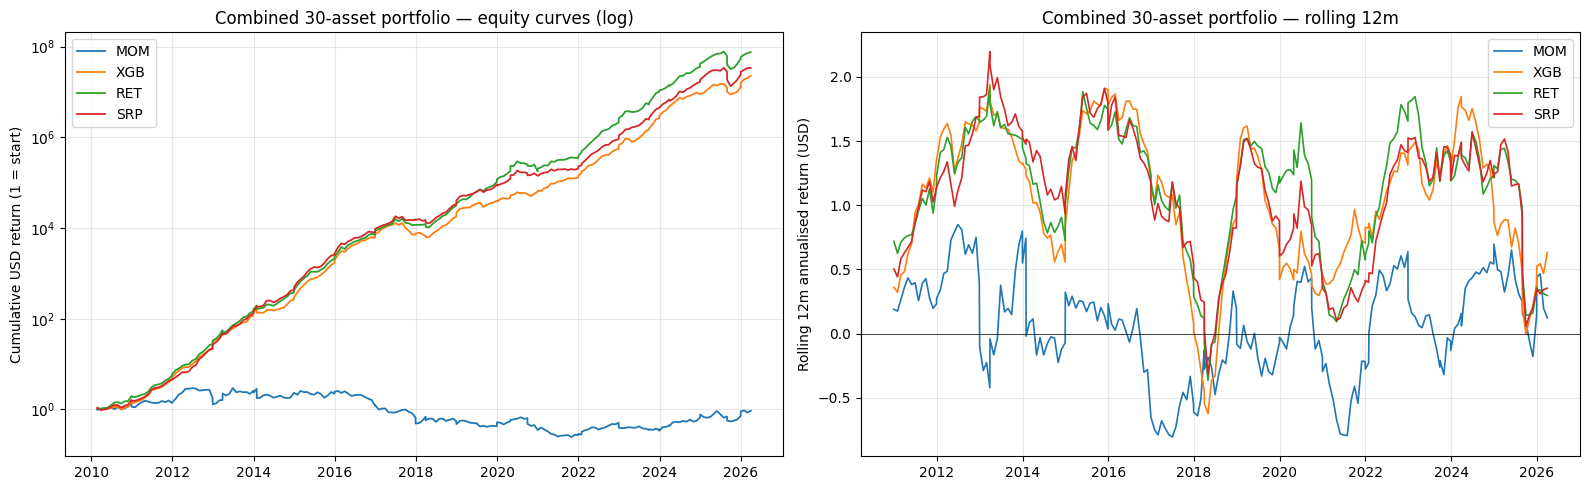

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
colors = {'MOM': '#1f77b4', 'XGB': '#ff7f0e', 'RET': '#2ca02c', 'SRP': '#d62728'}

ax = axes[0]
for name, c in colors.items():
    if name not in combined_results:
        continue
    port = combined_results[name]['portfolio']
    cum = (1 + port['ls_ret']).cumprod()
    ax.plot(port['date'], cum, label=name, color=c, linewidth=1.3)
ax.set_yscale('log')
ax.set_ylabel('Cumulative USD return (1 = start)')
ax.set_title('Combined 30-asset portfolio — equity curves (log)')
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
for name, c in colors.items():
    if name not in combined_results:
        continue
    port = combined_results[name]['portfolio']
    roll = port['ls_ret'].rolling(12).mean() * 12
    ax.plot(port['date'], roll, label=name, color=c, linewidth=1.2)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Rolling 12m annualised return (USD)')
ax.set_title('Combined 30-asset portfolio — rolling 12m')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/combined_usd_equity.png', dpi=150, bbox_inches='tight')
plt.show()


Strategy    Equity Ann    FX Ann  Total USD Ann   FX share
------------------------------------------------------------
MOM              8.0%    -0.1%          8.0%     -0.8%
XGB            103.1%    -0.8%        102.4%     -0.7%
RET            111.0%    -0.7%        110.3%     -0.7%
SRP            106.0%    -0.6%        105.4%     -0.6%


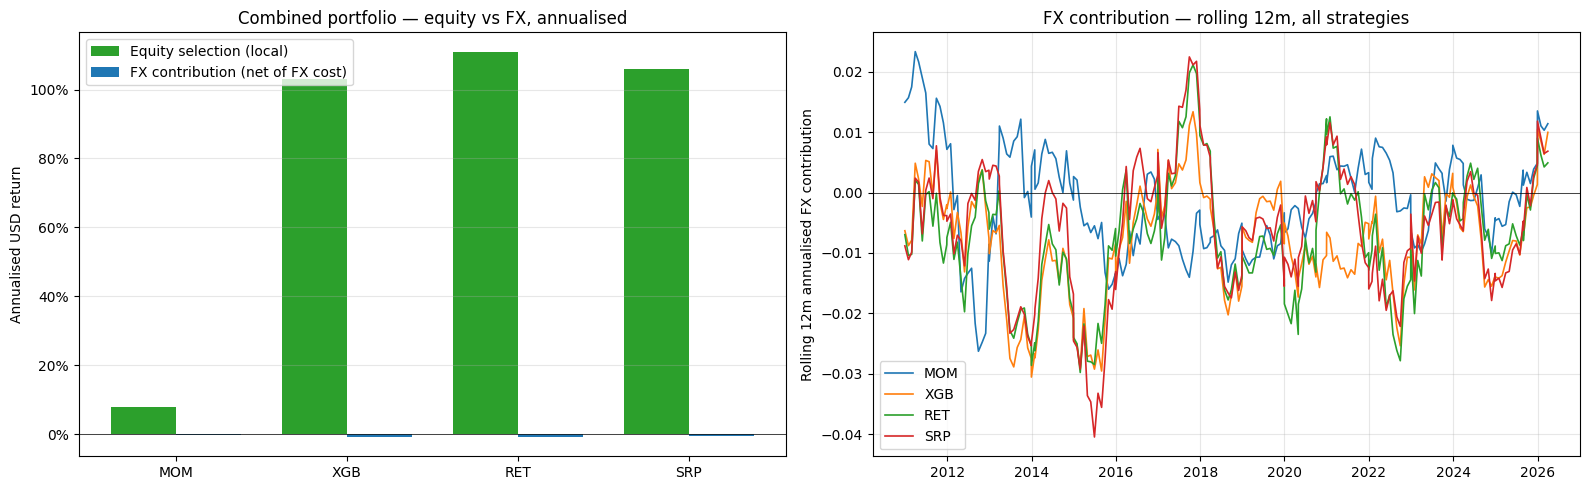

In [18]:
# ─── Source-of-returns decomposition: equity selection vs FX ────────────
# For a market-neutral L/S: r_USD = (1 + fx) * r_local
# So FX contribution (net of FX cost) = r_usd_combined - r_local_combined.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

decomp = {}
for name in ['MOM', 'XGB', 'RET', 'SRP']:
    # Combined local return = mean of each country's local L/S (Section A)
    parts = []
    for suffix in PILOT_COUNTRIES:
        port = all_results_fixed.get(suffix, {}).get(name, {}).get('portfolio')
        if port is None or port.empty:
            continue
        parts.append(port[['date', 'ls_ret']].rename(columns={'ls_ret': f'ls_{suffix}'}))
    if len(parts) < 2 or name not in combined_results:
        continue
    m = parts[0]
    for p in parts[1:]:
        m = m.merge(p, on='date', how='outer')
    m['r_local'] = m[[c for c in m.columns if c.startswith('ls_')]].mean(axis=1, skipna=True)
    m = m[['date', 'r_local']].dropna()

    usd = combined_results[name]['portfolio'][['date', 'ls_ret']].rename(columns={'ls_ret': 'r_usd'})
    d = m.merge(usd, on='date', how='inner').sort_values('date').reset_index(drop=True)
    d['r_fx'] = d['r_usd'] - d['r_local']
    decomp[name] = d

# ─── Summary table ──────────────────────────────────────────────────────
print(f'{"Strategy":<10s} {"Equity Ann":>11s} {"FX Ann":>9s} {"Total USD Ann":>14s} {"FX share":>10s}')
print('-' * 60)
for name, d in decomp.items():
    eq  = d['r_local'].mean() * 12
    fx_ = d['r_fx'].mean() * 12
    tot = d['r_usd'].mean() * 12
    share = fx_ / tot if abs(tot) > 1e-9 else np.nan
    print(f'{name:<10s} {eq:>10.1%} {fx_:>8.1%} {tot:>13.1%} {share:>9.1%}')

# ─── Visualisation ──────────────────────────────────────────────────────
colors = {'MOM': '#1f77b4', 'XGB': '#ff7f0e', 'RET': '#2ca02c', 'SRP': '#d62728'}
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: grouped bar chart — annualised equity vs FX per strategy
ax = axes[0]
names = list(decomp.keys())
x = np.arange(len(names))
eq_ann = [decomp[n]['r_local'].mean() * 12 for n in names]
fx_ann = [decomp[n]['r_fx'].mean() * 12 for n in names]
w = 0.38
ax.bar(x - w/2, eq_ann, w, label='Equity selection (local)', color='#2ca02c')
ax.bar(x + w/2, fx_ann, w, label='FX contribution (net of FX cost)', color='#1f77b4')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('Annualised USD return')
ax.set_title('Combined portfolio — equity vs FX, annualised')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax.legend(); ax.grid(alpha=0.3, axis='y')

# Right: rolling 12m FX contribution — one line per strategy
ax = axes[1]
for name, d in decomp.items():
    roll = d['r_fx'].rolling(12).mean() * 12
    ax.plot(d['date'], roll, label=name, color=colors[name], linewidth=1.2)
ax.axhline(0, color='black', linewidth=0.5)
ax.set_ylabel('Rolling 12m annualised FX contribution')
ax.set_title('FX contribution — rolling 12m, all strategies')
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/combined_usd_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
!pip install -q fortitudo_tech cvxopt


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [28]:
# Build monthly 5L+5S selections (RET signal) and per-stock return panels.
# NOTE: exchange month-end days differ (Canada 01-31, Australia 01-29, etc.)
# Snap all dates to the logical month-end so selections from all countries align.
import pandas as pd
import numpy as np

OOS_TS = pd.Timestamp(OOS_START)

def to_month_end(s):
    return s.dt.to_period('M').dt.to_timestamp('M').dt.normalize()

# 1. Selections per month: {month_end_date: {symbol: +1 long / -1 short}}
selections = {}
for suffix in PILOT_COUNTRIES:
    if suffix not in predictions_data:
        continue
    p = predictions_data[suffix][['symbol', 'date', 'ret_score']].dropna().copy()
    p['date'] = to_month_end(p['date'])
    p = p[p['date'] >= OOS_TS]
    for date, grp in p.groupby('date'):
        g = grp.sort_values('ret_score', ascending=False)
        longs  = g.head(5)['symbol'].tolist()
        shorts = g.tail(5)['symbol'].tolist()
        selections.setdefault(date, {})
        for s in longs:  selections[date][s] = +1
        for s in shorts: selections[date][s] = -1

sel_dates = sorted(selections.keys())
avg_names = np.mean([len(v) for v in selections.values()])
print(f'Selection months: {len(sel_dates)}  ({sel_dates[0].date()} -> {sel_dates[-1].date()})')
print(f'Avg names/month: {avg_names:.1f}  (target 30)')

# 2. Per-stock return panels from features_data (for cov) and fwd panel (for realization)
frames = []
for suffix in PILOT_COUNTRIES:
    if suffix not in features_data:
        continue
    df, _ = features_data[suffix]
    frames.append(df[['symbol', 'date', 'return', 'fwd_return']])
stock_df = pd.concat(frames, ignore_index=True)
stock_df['date'] = to_month_end(stock_df['date'])
stock_df = stock_df.drop_duplicates(subset=['symbol', 'date'])

ret_panel = stock_df.pivot_table(index='date', columns='symbol', values='return')
fwd_panel = stock_df.pivot_table(index='date', columns='symbol', values='fwd_return')
print(f'Return panel: {ret_panel.shape[0]} months x {ret_panel.shape[1]} unique symbols')

Selection months: 196  (2010-01-31 -> 2026-04-30)
Avg names/month: 30.0  (target 30)
Return panel: 434 months x 4138 unique symbols


In [29]:
# Single-leg optimizer: Mean-CVaR + entropy pooling + exposure stacking.
# Returns weights summing to 1 on the input asset set.
import fortitudo.tech as ft
import numpy as np

def optimize_leg(hist, W_MAX=0.30, B=100, N_RESAMPLE=50, P_FRONT=5, PF_IDX=2,
                 ALPHA=0.90, L_STACK=5, seed=None):
    """hist: (S, I) past returns. Returns (I,) weight vector, sum=1, 0<=w<=W_MAX."""
    S, I = hist.shape
    if I == 0:
        return np.zeros(0)
    if I == 1:
        return np.array([1.0])

    means = hist.mean(axis=0)
    cov   = np.cov(hist.T) + 1e-6 * np.eye(I)
    G = np.vstack((np.eye(I), -np.eye(I)))
    h = np.hstack((W_MAX * np.ones(I), np.zeros(I)))

    if seed is not None:
        np.random.seed(seed)
    try:
        return_sim = np.random.multivariate_normal(means, cov, (N_RESAMPLE, B))
    except np.linalg.LinAlgError:
        return np.ones(I) / I

    p_prior = np.ones((S, 1)) / S
    frontier_mean = np.full((I, P_FRONT, B), np.nan)

    for b in range(B):
        means_u = np.mean(return_sim[:, b, :], axis=0)
        try:
            q = ft.entropy_pooling(p_prior, A=hist.T, b=means_u[:, np.newaxis])
            R_w = hist * q * S
            cvar_b = ft.MeanCVaR(R_w, G, h, alpha=ALPHA)
            frontier_mean[:, :, b] = cvar_b.efficient_frontier(P_FRONT)
        except Exception:
            pass

    good = ~np.isnan(frontier_mean[0, PF_IDX, :])
    if good.sum() < L_STACK * 2:
        return np.ones(I) / I
    return ft.exposure_stacking(L_STACK, frontier_mean[:, PF_IDX, good])

In [30]:
# Rolling monthly loop: for each date, optimize long leg + short leg, compute realized ret.
from time import time

LOOKBACK  = 36
MIN_HIST  = 24      # drop names with < 24 months of past data
W_MAX_LEG = 0.30    # max 30% within a leg

opt30_returns = {}   # date -> realized L/S return
weight_log    = {}   # date -> (long_symbols, w_long, short_symbols, w_short)

np.random.seed(3)
t0 = time()
n_total = len(sel_dates)

for i_t, date_t in enumerate(sel_dates):
    sel = selections[date_t]
    longs  = [s for s, sign in sel.items() if sign == +1]
    shorts = [s for s, sign in sel.items() if sign == -1]

    if date_t not in ret_panel.index:
        continue
    end_idx = ret_panel.index.get_loc(date_t)
    if end_idx < LOOKBACK:
        continue

    hist_l = ret_panel.iloc[end_idx - LOOKBACK:end_idx][longs]
    hist_s = ret_panel.iloc[end_idx - LOOKBACK:end_idx][shorts]

    # Drop names without enough history
    l_ok = hist_l.count() >= MIN_HIST
    s_ok = hist_s.count() >= MIN_HIST
    longs_v  = [n for n, ok in zip(longs,  l_ok) if ok]
    shorts_v = [n for n, ok in zip(shorts, s_ok) if ok]
    if len(longs_v) < 3 or len(shorts_v) < 3:
        continue

    Hl = hist_l[longs_v ].fillna(0).values
    Hs = hist_s[shorts_v].fillna(0).values

    w_long  = optimize_leg(Hl,      W_MAX=W_MAX_LEG)
    w_short = optimize_leg(-Hs,     W_MAX=W_MAX_LEG)  # negate: a "good short" looks like a long

    if date_t not in fwd_panel.index:
        continue
    fl = fwd_panel.loc[date_t, longs_v ].fillna(0).values
    fs = fwd_panel.loc[date_t, shorts_v].fillna(0).values
    r_ls = (w_long * fl).sum() - (w_short * fs).sum()
    opt30_returns[date_t] = r_ls
    weight_log[date_t] = (longs_v, w_long, shorts_v, w_short)

    if i_t % 12 == 0 or i_t == n_total - 1:
        print(f'  {date_t.date()}  {i_t+1}/{n_total}  ({time()-t0:.0f}s)')

opt30_series = pd.Series(opt30_returns).sort_index()
print(f'\nOptimized months: {len(opt30_series)}')

  2010-01-31  1/196  (5s)
  2011-01-31  13/196  (294s)
  2012-01-31  25/196  (500s)
  2013-01-31  37/196  (755s)
  2014-01-31  49/196  (960s)
  2015-01-31  61/196  (1186s)
  2016-01-31  73/196  (1497s)
  2017-01-31  85/196  (1728s)
  2018-01-31  97/196  (2091s)
  2019-01-31  109/196  (2357s)
  2020-01-31  121/196  (2607s)
  2021-01-31  133/196  (2930s)
  2022-01-31  145/196  (3210s)
  2023-01-31  157/196  (3446s)
  2024-01-31  169/196  (3826s)
  2025-01-31  181/196  (3964s)
  2026-01-31  193/196  (4215s)

Optimized months: 195


Strategy                               Ann.Ret   Ann.Vol   Sharpe    MaxDD   t-stat  Months
-----------------------------------------------------------------------------------------------
EW 30-asset RET (Section C)            110.9%    35.1%    3.163  -49.4%    10.77     139
Opt 30-asset RET (Section E, two-leg)    96.5%    47.2%    2.044  -34.3%     6.96     139


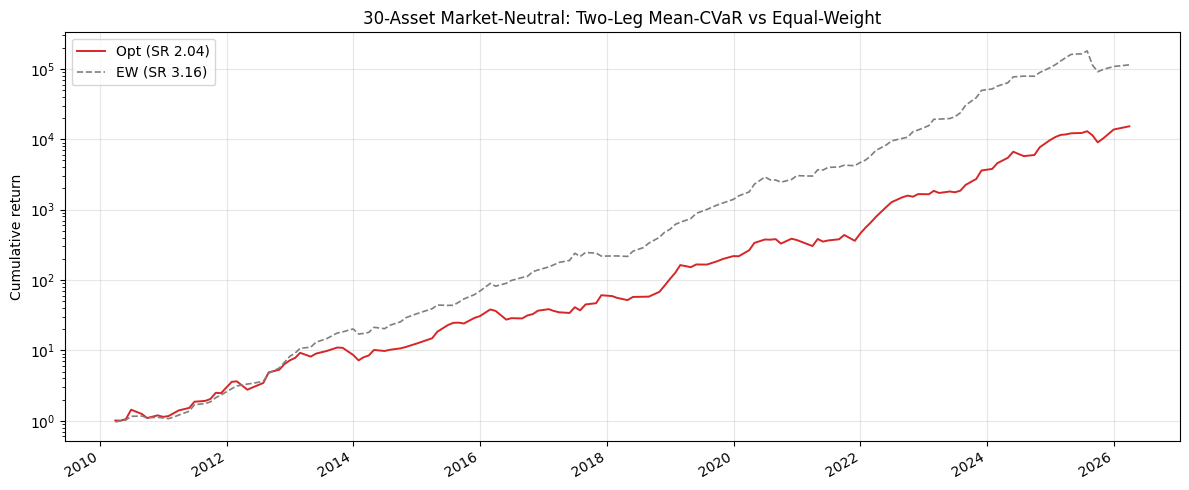

In [31]:
# Backtest: compare to Section C equal-weight RET baseline.
from portfolio import compute_performance
import matplotlib.pyplot as plt

ew_ret = combined_results['RET']['portfolio'].set_index('date')['ls_ret'] \
         if 'RET' in combined_results else pd.Series(dtype=float)

common = opt30_series.index.intersection(ew_ret.index)
opt_a = opt30_series.loc[common]
ew_a  = ew_ret.loc[common]

opt_port = pd.DataFrame({'date': opt_a.index, 'ls_ret': opt_a.values})
ew_port  = pd.DataFrame({'date': ew_a.index,  'ls_ret': ew_a.values})

m_opt = compute_performance(opt_port, 'OPT30')
m_ew  = compute_performance(ew_port,  'EW30')

print(f'{"Strategy":<36s} {"Ann.Ret":>9s} {"Ann.Vol":>9s} {"Sharpe":>8s} {"MaxDD":>8s} {"t-stat":>8s} {"Months":>7s}')
print('-' * 95)
for name, m in [('EW 30-asset RET (Section C)', m_ew),
                ('Opt 30-asset RET (Section E, two-leg)', m_opt)]:
    print(f'{name:<36s} {m["mean_annual"]:>8.1%} {m["std_annual"]:>8.1%} '
          f'{m["sharpe"]:>8.3f} {m["max_drawdown"]:>7.1%} {m["t_stat"]:>8.2f} {m["n_months"]:>7d}')

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
(1 + opt_a).cumprod().plot(ax=ax, label=f'Opt (SR {m_opt["sharpe"]:.2f})',
                            color='#d62728', linewidth=1.4)
(1 + ew_a ).cumprod().plot(ax=ax, label=f'EW (SR {m_ew["sharpe"]:.2f})',
                            color='#7f7f7f', linestyle='--', linewidth=1.2)
ax.set_yscale('log')
ax.set_title('30-Asset Market-Neutral: Two-Leg Mean-CVaR vs Equal-Weight')
ax.set_ylabel('Cumulative return')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('results/opt_30asset_twoleg.png', dpi=150, bbox_inches='tight')
plt.show()